In [11]:
import matplotlib.pyplot as plt
import ants
import os
import matplotlib.pyplot as plt
import numpy as np

# Data Visualization

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pip install antspyx

Lets visualize some of the mouse mri brain scans

In [4]:


# Define path
folder = '/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans'

# Get a few sample files (limit to 3–4 for now)
nii_files = sorted([f for f in os.listdir(folder) if f.endswith('.nii.gz')])[:5]

# Load them using ANTs
subjects = [ants.image_read(os.path.join(folder, f)) for f in nii_files]


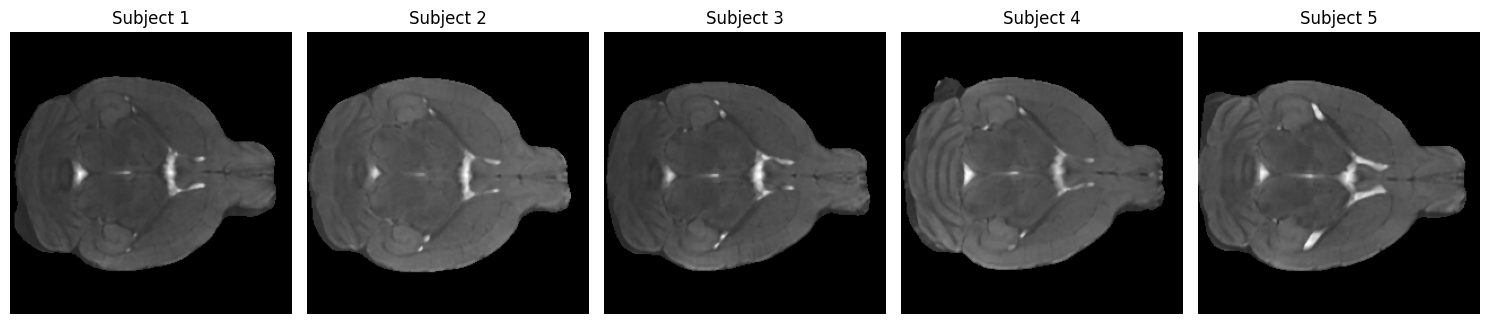

In [5]:
# Plot a central slice from each subject
z_indices = [img.shape[2] // 2 for img in subjects]

plt.figure(figsize=(15, 5))
for i, (img, z) in enumerate(zip(subjects, z_indices)):
    plt.subplot(1, len(subjects), i+1)
    plt.imshow(img.numpy()[:, :, z], cmap='gray')
    plt.title(f'Subject {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


Now lets visualize the template scan

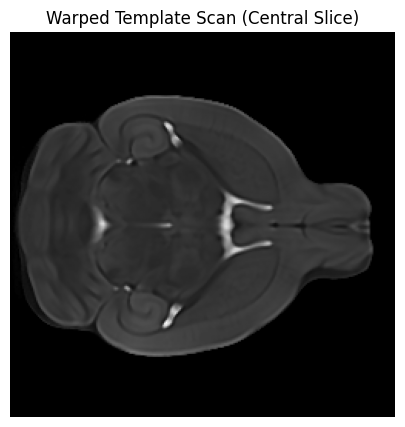

In [14]:
template_path = "/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/template_scan/warped_template.nii.gz"
# Load the warped template
template = ants.image_read(template_path)
template_np = template.numpy()

# Choose a central slice
z = template_np.shape[2] // 2

# Plot
plt.figure(figsize=(6, 5))
plt.title("Warped Template Scan (Central Slice)")
plt.imshow(template_np[:, :, z], cmap='gray')
plt.axis('off')
plt.show()


Now lets check to see if the original mri scans have been affine aligned

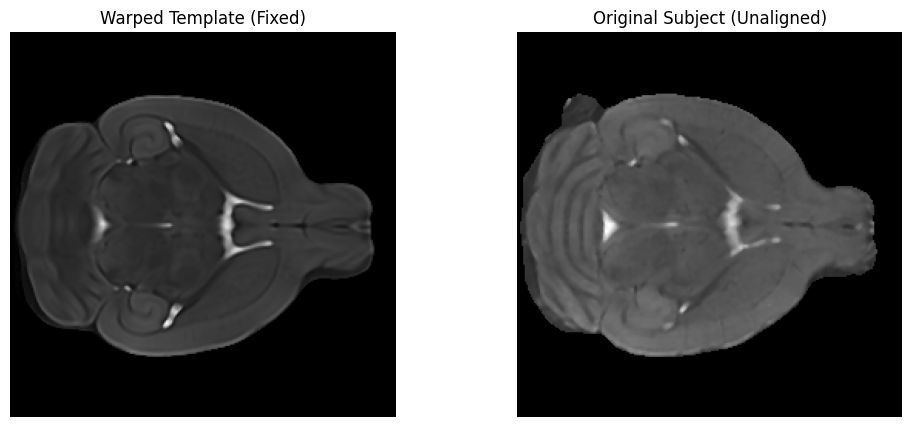

In [7]:

# Load template and subject scan (before alignment)
template = ants.image_read('/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/template_scan/warped_template.nii.gz')
subject = ants.image_read('/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/20210713_155634_RetromerSRA_PD_hom_g2_04_ID428_TP1_1_1_iso60_WB_mean.nii.gz')

# Convert to numpy
template_np = template.numpy()
subject_np = subject.numpy()

# Choose central z-slice
z_template = template_np.shape[2] // 2
z_subject = subject_np.shape[2] // 2

# Plot side-by-side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Warped Template (Fixed)")
plt.imshow(template_np[:, :, z_template], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Original Subject (Unaligned)")
plt.imshow(subject_np[:, :, z_subject], cmap='gray')
plt.axis('off')

plt.show()


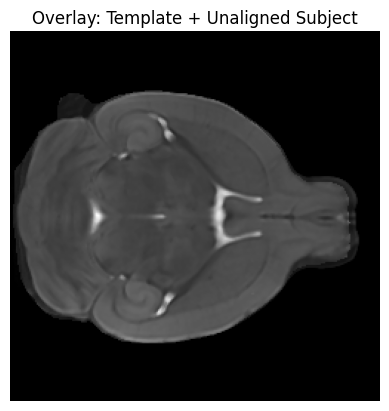

In [8]:

# Resample subject to match template (shape-wise)
subject_resampled = ants.resample_image_to_target(subject, template)

# Normalize both for visualization
template_np = (template.numpy() - template.numpy().min()) / (np.ptp(template.numpy()))
subject_np = (subject_resampled.numpy() - subject_resampled.numpy().min()) / (np.ptp(subject_resampled.numpy()))

# Choose central slice
z = template_np.shape[2] // 2
overlay = 0.5 * template_np[:, :, z] + 0.5 * subject_np[:, :, z]

plt.imshow(overlay, cmap='gray')
plt.title("Overlay: Template + Unaligned Subject")
plt.axis('off')
plt.show()


The MRI scans have not been affine aligned

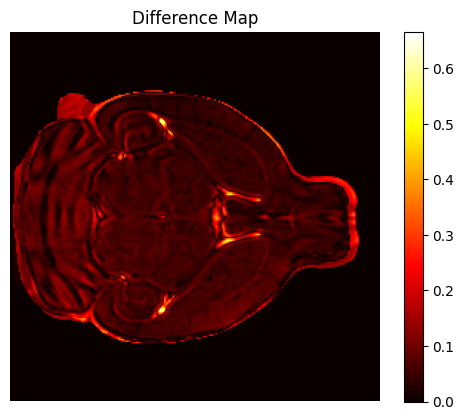

In [9]:
diff = np.abs(template_np - subject_np)

plt.imshow(diff[:, :, z], cmap='hot')
plt.title("Difference Map")
plt.axis('off')
plt.colorbar()
plt.show()


# Data Preprocessing

affinely align the mouse brain MRI data set to the template scan. This is a linear rough alignment so that Voxelmorph will only be reponsible for learning nonlinear deformable alignment/registration.

In [12]:
mi = ants.image_read('/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/20210713_155634_RetromerSRA_PD_hom_g2_04_ID428_TP1_1_1_iso60_WB_mean.nii.gz')
fi = ants.image_read('/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/template_scan/warped_template.nii.gz')

In [15]:
mytx = ants.registration(fixed=fi , moving=mi , type_of_transform = ('Affine') )
mywarpedimage = ants.apply_transforms(fixed=fi, moving=mi, transformlist=mytx['fwdtransforms'] )

In [18]:
# Convert to numpy
fixed_np = fi.numpy()
warped_np = mywarpedimage.numpy()

# Choose a central slice (z-axis)
z = fixed_np.shape[2] // 2

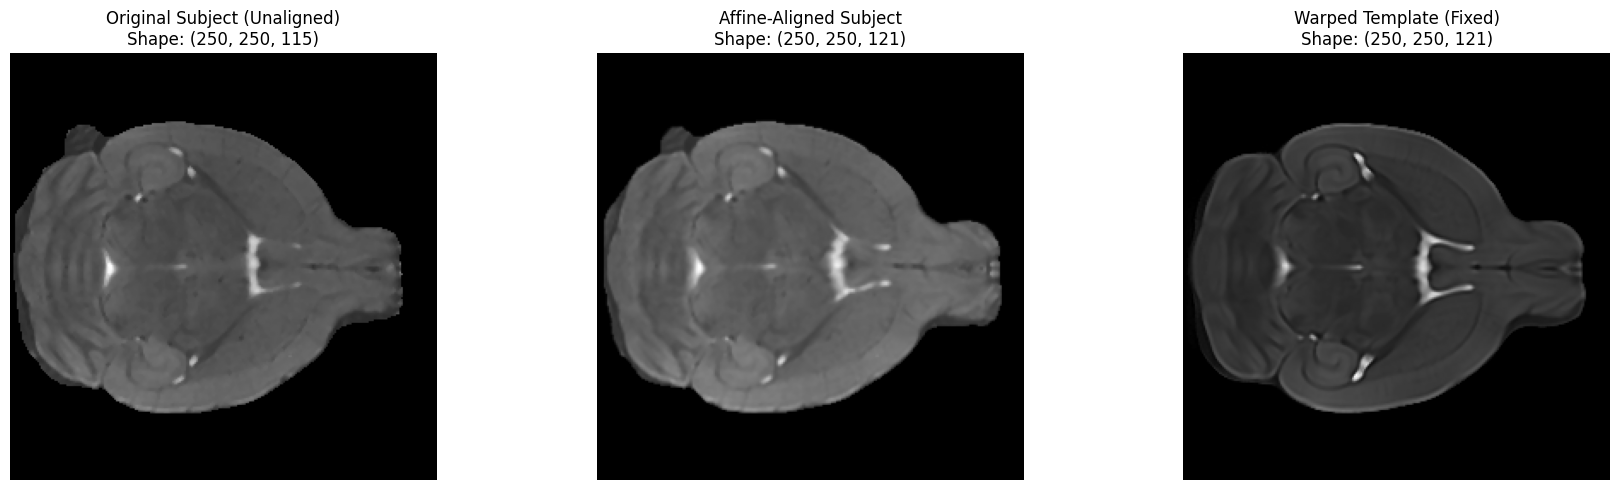

In [26]:
import matplotlib.pyplot as plt

# Convert all to numpy
subject_np = mi.numpy()         # Original subject (unaligned)
warped_np = mywarpedimage.numpy()  # Affine-aligned subject
fixed_np = fi.numpy()           # Warped template (fixed image)

# Use same central slice index for consistency
z = fixed_np.shape[2] // 2

# Plot all three with shapes
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title(f"Original Subject (Unaligned)\nShape: {subject_np.shape}")
plt.imshow(subject_np[:, :, z], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Affine-Aligned Subject\nShape: {warped_np.shape}")
plt.imshow(warped_np[:, :, z], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"Warped Template (Fixed)\nShape: {fixed_np.shape}")
plt.imshow(fixed_np[:, :, z], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


The ANTs registration function will do affine alignment as well as resampling to match the subject slice number (115) to the template slice number (121)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Convert to numpy
subject_np = mi.numpy()
warped_np = mywarpedimage.numpy()
template_np = fi.numpy()

# Determine max depth
max_depth = max(subject_np.shape[2], warped_np.shape[2], template_np.shape[2])

# Function to safely fetch slice or return blank
def get_slice(volume, z):
    if z < volume.shape[2]:
        return volume[:, :, z]
    else:
        return np.zeros_like(volume[:, :, 0])

# Display function
def show_slice(z):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].imshow(get_slice(subject_np, z), cmap='gray')
    axs[0].set_title(f"Original Subject\nShape: {subject_np.shape}")
    axs[0].axis('off')

    axs[1].imshow(get_slice(warped_np, z), cmap='gray')
    axs[1].set_title(f"Affine-Aligned Subject\nShape: {warped_np.shape}")
    axs[1].axis('off')

    axs[2].imshow(get_slice(template_np, z), cmap='gray')
    axs[2].set_title(f"Template (Fixed)\nShape: {template_np.shape}")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

# Create slider
widgets.interact(show_slice, z=widgets.IntSlider(min=0, max=max_depth-1, step=1, value=max_depth//2));


interactive(children=(IntSlider(value=60, description='z', max=120), Output()), _dom_classes=('widget-interact…

Lets loop through the subjects and affine align all of them and save them in a separate directory

In [33]:
import ants
import os

template_path = "/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/template_scan/warped_template.nii.gz"
subjects_dir = "/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans"
aligned_dir = "/content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned"
log_path = os.path.join(aligned_dir, "failed_alignments.txt")

# Make output directory if it doesn't exist
os.makedirs(aligned_dir, exist_ok=True)

# Load template
template = ants.image_read(template_path)

# Open log file
with open(log_path, "w") as log_file:
    for fname in os.listdir(subjects_dir):
        if not fname.endswith('.nii') and not fname.endswith('.nii.gz'):
            continue

        subject_path = os.path.join(subjects_dir, fname)

        try:
            subject_img = ants.image_read(subject_path)

            # Affine registration
            reg = ants.registration(fixed=template, moving=subject_img, type_of_transform='Affine')

            # Apply transform to moving image
            aligned_img = ants.apply_transforms(
                fixed=template,
                moving=subject_img,
                transformlist=reg['fwdtransforms'],
                interpolator='linear'
            )

            # Save aligned image
            output_path = os.path.join(aligned_dir, f"aligned_{fname}")
            aligned_img.to_file(output_path)

            print(f"Aligned and saved: {output_path}")

        except Exception as e:
            log_file.write(f"{fname}\t{str(e)}\n")
            print(f"Failed to align: {fname} — error logged.")

Aligned and saved: /content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned/aligned_20211110_140056_RetromerSRA_PD_wt_g1_08_1_1_iso60_WB_mean.nii.gz
Aligned and saved: /content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned/aligned_20210915_220047_RetromerSRA_PD_homo_g3_02_ID566_homo_TP1_1_1_iso60_WB_mean.nii.gz
Aligned and saved: /content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned/aligned_20210821_172807_RetromerSRA_Sorla_wt_g1_06_ID511_wt_TP1__1_1_iso60_WB_mean.nii.gz
Aligned and saved: /content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned/aligned_20211122_171225_RetromerSRA_Sorl_het_g9_01_TP1_1_1_iso60_WB_mean.nii.gz
Aligned and saved: /content/drive/MyDrive/DL_Final_Project/Mouse_dataset/RT_SRA_MouseMRIRegistration/subject_scans/affine_aligned/aligned_20210713_

In [35]:
import os, sys

# third party imports
import numpy as np
import tensorflow as tf

In [ ]:
import sys
print(sys.version)


In [7]:
!pip -q install git+https://github.com/adalca/neurite.git@0776a575eadc3d10d6851a4679b7a305f3a31c65
!pip -q install git+https://github.com/voxelmorph/voxelmorph.git@375a1492bb8781cbbaf22f0ca2973e5121484f99

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [3]:
!pip install tensorflow_addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow_addons]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [1]:
# local imports
import voxelmorph as vxm
import neurite as ne


ImportError: Please install tensorflow to use this neurite backend

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import voxelmorph as vxm

ImportError: cannot import name 'mean_absolute_error' from 'tensorflow.keras.losses' (/usr/local/lib/python3.11/dist-packages/keras/_tf_keras/keras/losses/__init__.py)